In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
image = np.zeros((100,100))

In [3]:
image[:,:3] = 50
image[:,3:] = 200
image

array([[ 50.,  50.,  50., ..., 200., 200., 200.],
       [ 50.,  50.,  50., ..., 200., 200., 200.],
       [ 50.,  50.,  50., ..., 200., 200., 200.],
       ...,
       [ 50.,  50.,  50., ..., 200., 200., 200.],
       [ 50.,  50.,  50., ..., 200., 200., 200.],
       [ 50.,  50.,  50., ..., 200., 200., 200.]], shape=(100, 100))

In [4]:
kernel_vertical = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
],
    dtype=np.float32
)

In [5]:
padding = 0 
stride = 1
step_x, step_y = kernel_vertical.shape
output_size = int(np.floor(((image.shape[0] - kernel_vertical.shape[0]+ 2 * padding) / stride)+ 1)) # returns 5


In [6]:
output = np.zeros((output_size, output_size), dtype=np.float32) # shape  (5,5)

for r in range(output_size):
    for c in range(output_size):
        window = image[r:r + step_x, c: c + step_y]
        output[r,c] = np.sum(window * kernel_vertical)
output

array([[  0., 450., 450., ...,   0.,   0.,   0.],
       [  0., 450., 450., ...,   0.,   0.,   0.],
       [  0., 450., 450., ...,   0.,   0.,   0.],
       ...,
       [  0., 450., 450., ...,   0.,   0.,   0.],
       [  0., 450., 450., ...,   0.,   0.,   0.],
       [  0., 450., 450., ...,   0.,   0.,   0.]],
      shape=(98, 98), dtype=float32)

## Horizontal kernel

In [7]:
kernel_horizontal = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1],
],
    dtype = np.float32
)

In [8]:
image_2 = np.zeros((100, 100))


In [9]:
image_2[:3,:] = 20
image_2[3:,:] = 200


In [10]:
padding = 3
stride = 1

In [11]:
padded_image = np.pad(
    image_2,
    pad_width = padding,
    mode="constant",
    constant_values = 0
)

In [12]:
output_size = int(np.floor((image_2.shape[0] - kernel_horizontal.shape[0] + 2 * padding) / stride) + 1)

In [13]:
output = np.zeros((output_size, output_size), dtype=np.float32)

In [14]:
for r in range(output_size):
    
    for c in range(output_size):
        
        window = padded_image[r:r +3, c:c + 3]
        
        output[r,c] = np.sum(window * kernel_horizontal)
        
print(output)

[[   0.    0.    0. ...    0.    0.    0.]
 [   0.   20.   40. ...   40.   20.    0.]
 [   0.   20.   40. ...   40.   20.    0.]
 ...
 [   0. -200. -400. ... -400. -200.    0.]
 [   0. -200. -400. ... -400. -200.    0.]
 [   0.    0.    0. ...    0.    0.    0.]]


In [15]:
cv2.filter2D(image_2, -1 , kernel_horizontal, borderType=cv2.BORDER_CONSTANT)

array([[  40.,   60.,   60., ...,   60.,   60.,   40.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [ 360.,  540.,  540., ...,  540.,  540.,  360.],
       ...,
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [   0.,    0.,    0., ...,    0.,    0.,    0.],
       [-400., -600., -600., ..., -600., -600., -400.]], shape=(100, 100))

[ WARN:0@0.788] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


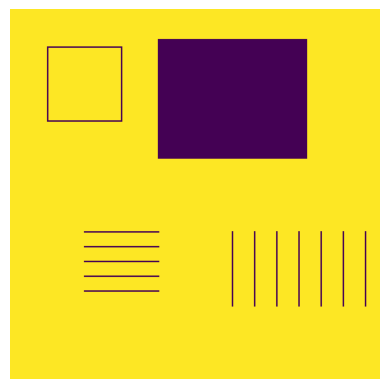

In [16]:
canvas = np.full((250,250), 255, dtype=np.float32)

cv2.rectangle(canvas, (25, 25),(75, 75), 0,thickness=1)
cv2.rectangle(canvas, (100, 20),(200, 100), 0,thickness=-1)


for x in range(150, 250, 15):
    cv2.line(canvas, (x, 150), (x, 200), 0,thickness =1)
for y in range(150, 200, 10):
    cv2.line(canvas, (50, y), (100, y), 0,thickness=1)

cv2.imwrite("d:Test.png", canvas)

plt.imshow(canvas, )
plt.axis("off")
plt.show()


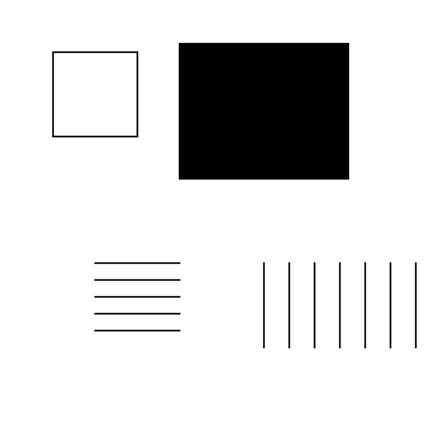

In [17]:
# plt.figure(figsize=(6,6))
plt.imshow(cv2.imread("d:Test.png"))
plt.tight_layout()
plt.axis("off")
plt.show()

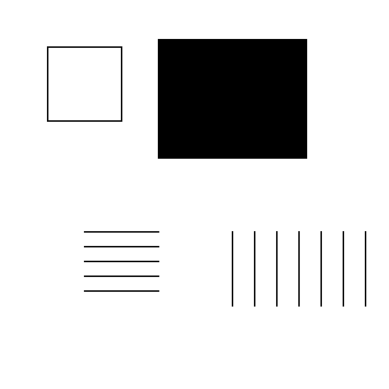

In [18]:
image_bgr = cv2.imread("d:Test.png")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [19]:
image_bgr.shape

(250, 250, 3)

In [20]:
image_rgb.shape

(250, 250, 3)

In [21]:
resized = cv2.resize(image_bgr,(256, 256))
resized.shape

(256, 256, 3)

In [22]:
r, b, g = cv2.split(resized)
r.shape, b.shape, g.shape

((256, 256), (256, 256), (256, 256))

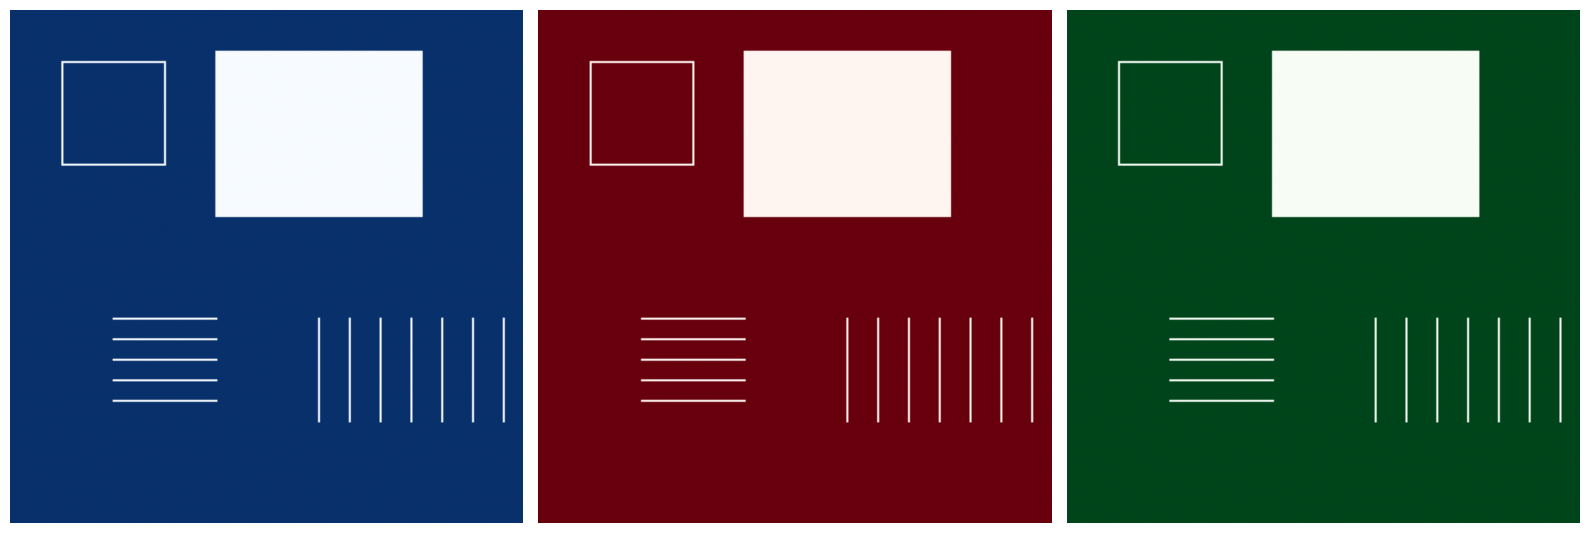

In [23]:
b , r, g = cv2.split(image_bgr)
fig, axes = plt.subplots(1,3, figsize=(16, 6))

cmaps=["Blues", "Reds", "Greens"]

images = [b ,r ,g]

for ax, img, c in zip(axes, images, cmaps):
    ax.imshow(img, cmap=c)
    ax.axis("off")
    
plt.tight_layout()
plt.show()



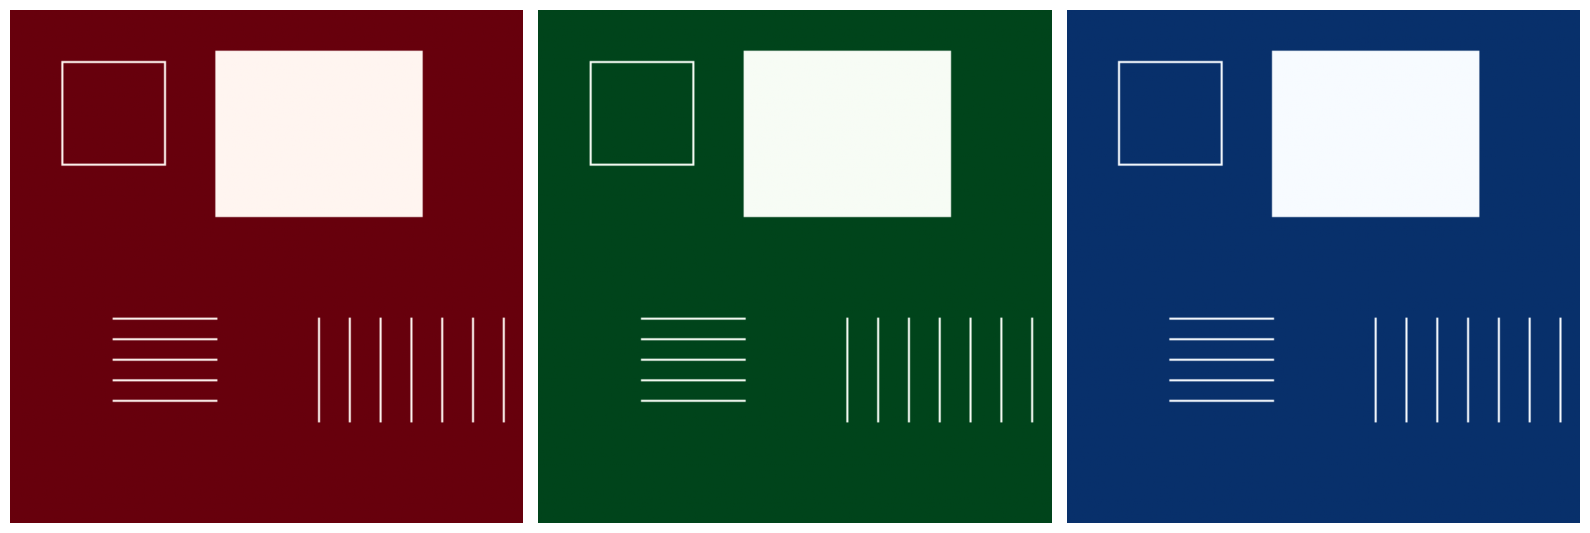

In [24]:
r, g, b = cv2.split(image_rgb)

fix , axes = plt.subplots(1,3, figsize=(16,8))

cmaps = ["Reds", "Greens", "Blues"]

images = [r, g, b]

for ax, img, c in zip(axes, images, cmaps):
    ax.imshow(img, cmap=c)
    ax.axis("off")
    
plt.tight_layout()
plt.show()

In [25]:
image_merged = cv2.merge([r, g, b])
image_merged.shape

(250, 250, 3)

In [26]:
cv2.imread("d:Test.png").shape

(250, 250, 3)

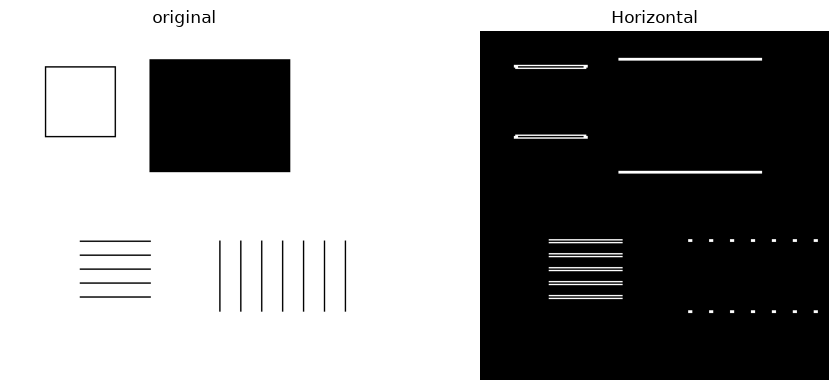

In [27]:
image = cv2.imread("d:Test.png")

kernel_horizontal = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1],
],
    dtype = np.float32
)

h = cv2.filter2D(image, cv2.CV_64F, kernel_horizontal)
h = cv2.convertScaleAbs(h)

fix, axes = plt.subplots(1,2, figsize=(10,4))

for ax, img, title in zip(axes, [image, h], ["original", "Horizontal"]):
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    ax.set_title(title)
    
plt.tight_layout()
plt.show()



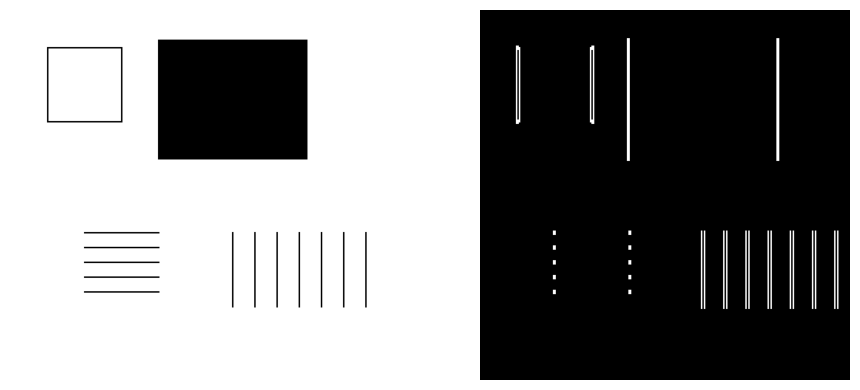

In [28]:
vertical_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])

v = cv2.filter2D(image, cv2.CV_64F, vertical_kernel)

v = cv2.convertScaleAbs(v)

fig , axes = plt.subplots(1,2, figsize=(10,4))

for ax, img , t in zip(axes, [image, v], ["Original", "Vertical Kernel"]):
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    
plt.tight_layout()
plt.show()

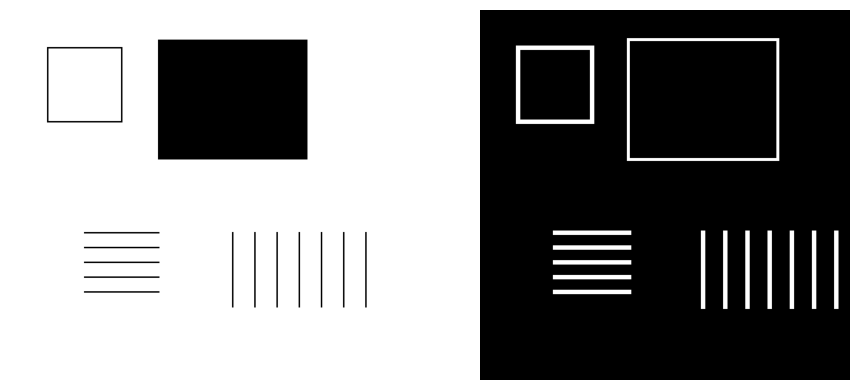

In [29]:
edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])

edge_filter = cv2.filter2D(image, cv2.CV_64F, edge_kernel)
edge_filter = cv2.convertScaleAbs(edge_filter)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

for ax, img, title in zip(axes, [image, edge_filter], ["Original", "Edge detecter"]):
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    
plt.tight_layout()
plt.show()

In [30]:
# image = np.full((7,7), 80, dtype=np.float32)

# edge_kernel = np.array([
#     [-1, -1, -1],
#     [-1,  7, -1],
#     [-1, -1, -1],
# ])
# test = cv2.filter2D(image, cv2.CV_32F, edge_kernel, borderType=cv2.BORDER_CONSTANT)
# test = cv2.convertScaleAbs(test)
# plt.imshow(test, cmap="gray")
# plt.show()

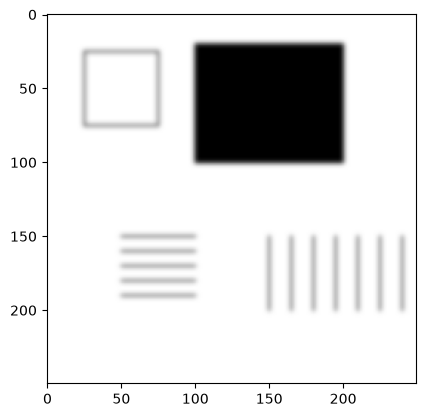

In [31]:
gassuain_blur = cv2.GaussianBlur(image, (9, 9), 0)

plt.imshow(gassuain_blur)
plt.show()


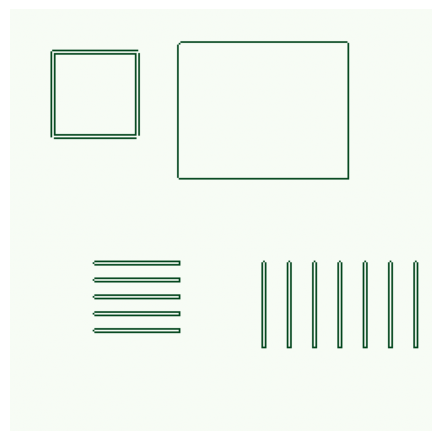

In [32]:
test_cany = cv2.GaussianBlur(image, (1,1), 0)
test_cany = cv2.Canny(test_cany, threshold1=300, threshold2=700)
plt.imshow(test_cany, cmap="Greens")
plt.tight_layout()
plt.axis("off")
plt.show()

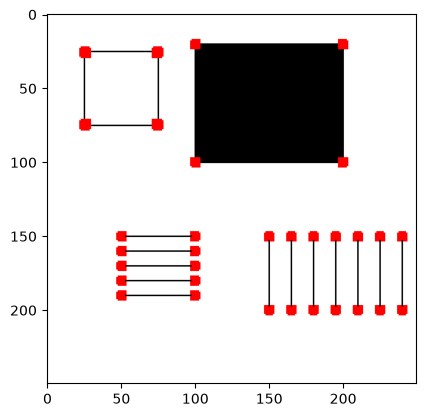

In [33]:
image = cv2.imread("d:Test.png", cv2.IMREAD_GRAYSCALE)
image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
g = np.float32(image)

harris = cv2.cornerHarris(g, blockSize=5, ksize=3, k=0.04)
r =  cv2.dilate(harris, None)
m = r > 0.01 * r.max()
image_color[m] = [0,0,255]

plt.imshow(cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB))
plt.show()

In [34]:
gray_image = cv2.imread("d:Test.png", cv2.IMREAD_GRAYSCALE)
color_image = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)
gray_float = np.float32(gray_image)

corner_response = cv2.cornerHarris(gray_float,blockSize=5,ksize=3,k=0.04)
corner_response_dilated = cv2.dilate(corner_response, None),

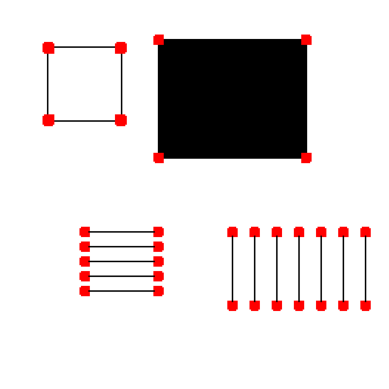

In [35]:
# Load the image in grayscale
gray_image = cv2.imread("d:Test.png", cv2.IMREAD_GRAYSCALE)

# Create a color version of the image so we can draw colored corners
color_image = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)

# Harris corner detector requires a float32 image
gray_float = np.float32(gray_image)

# Compute the Harris corner response
corner_response = cv2.cornerHarris(
    gray_float,
    blockSize=5,
    ksize=3,
    k=0.04
)

# Dilate the corner response to make corner regions more visible
corner_response_dilated = cv2.dilate(corner_response, None)

# Create a mask of strong corners
corner_mask = corner_response_dilated > 0.01 * corner_response_dilated.max()

# Mark detected corners in red (BGR format)
color_image[corner_mask] = [0, 0, 255]

# Convert BGR to RGB for displaying with Matplotlib
display_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)

# Show the result
plt.imshow(display_image)
plt.axis("off")
plt.show()